In [1]:
# Imports necesarios para el notebook
import random

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
from greedy import greedy_monedas

from util import time_algorithm

# Siempre seteamos la seed de aleatoridad para que los # resultados sean reproducibles
random.seed(12345)
np.random.seed(12345)

sns.set_theme()

In [2]:
x = np.linspace(100, 1_000_000, 20).astype(int)

def get_random_cant_monedas(s):
    # devuelve un array aleatorio de numeros mayores a 0 
    return [random.randint(1, 50) for _ in range(s)]

results = time_algorithm(greedy_monedas, x, lambda s: [get_random_cant_monedas(s)])

print(results)

{np.int64(100): 0.0, np.int64(52726): 0.01759781837463379, np.int64(105352): 0.039824628829956056, np.int64(157978): 0.05299556255340576, np.int64(210605): 0.07094788551330566, np.int64(263231): 0.09542996883392334, np.int64(315857): 0.09954004287719727, np.int64(368484): 0.11796138286590577, np.int64(421110): 0.13177499771118165, np.int64(473736): 0.1555718183517456, np.int64(526363): 0.1771982192993164, np.int64(578989): 0.18135485649108887, np.int64(631615): 0.20582268238067628, np.int64(684242): 0.2188213586807251, np.int64(736868): 0.23152413368225097, np.int64(789494): 0.2507220029830933, np.int64(842121): 0.2603677988052368, np.int64(894747): 0.27959294319152833, np.int64(947373): 0.3076399564743042, np.int64(1000000): 0.3377354860305786}


Text(0, 0.5, 'Tiempo de ejecución (s)')

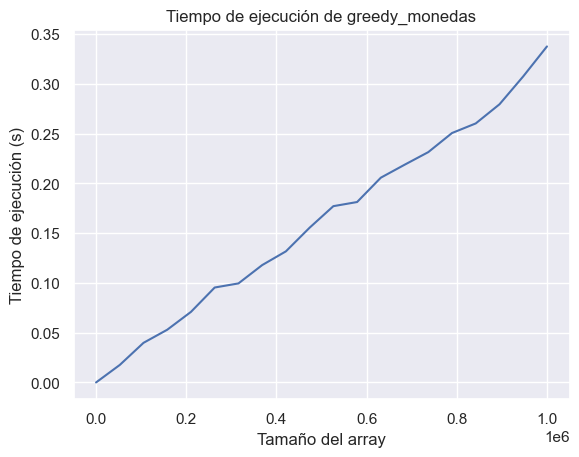

In [3]:
ax: plt.Axes
fig, ax = plt.subplots()
ax.plot(x, [results[i] for i in x], label="Medición")
ax.set_title('Tiempo de ejecución de greedy_monedas')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Tiempo de ejecución (s)')


In [4]:
# scipy nos pide una función que recibe primero x y luego los parámetros a ajustar:
f = lambda x, c1, c2: c1 * x * np.log(x) + c2 

c, pcov = sp.optimize.curve_fit(f, x, [results[n] for n in x])

print(f"c_1 = {c[0]}, c_2 = {c[1]}")
r = np.sum((c[0] * x * np.log(x) + c[1] - [results[n] for n in x])**2)
print(f"Error cuadrático total: {r}")

c_1 = 2.2805334231777323e-08, c_2 = 0.009459888579373375
Error cuadrático total: 0.000823415809507998


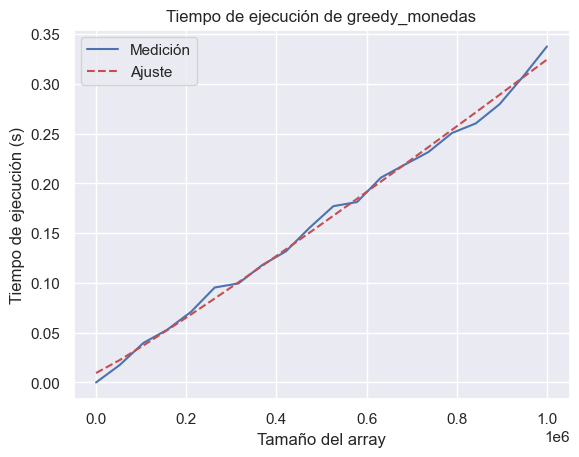

In [5]:
ax.plot(x, [c[0] * n * np.log(n) + c[1] for n in x], 'r--', label="Ajuste")
ax.legend()
fig

Text(0, 0.5, 'Error absoluto (s)')

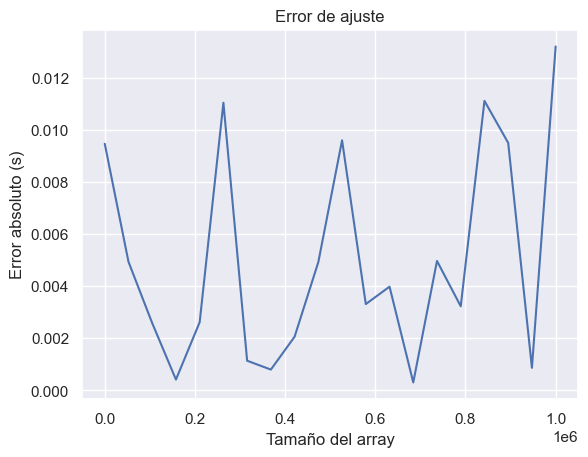

In [6]:
ax: plt.Axes
fig, ax = plt.subplots()
errors = [np.abs(c[0] * n * np.log(n) + c[1] - results[n]) for n in x]
ax.plot(x, errors)
ax.set_title('Error de ajuste')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Error absoluto (s)')